In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [3]:
data = {
    "Patient_ID":["P001","P002","P003","P004","P005","P006","P007","P008","P009","P010",
                  "P011","P012","P013","P014","P015","P016","P017","P018","P019","P020"],

    "Age":[25,45,60,35,52,29,40,65,50,27,
           38,55,48,33,70,42,58,30,46,62],

    "Gender":["Male","Female","Male","Female","Male","Female","Male","Female","Male","Female",
              "Male","Female","Male","Female","Male","Female","Male","Female","Male","Female"],

    "Blood_Pressure":[120,140,160,118,150,110,145,170,155,115,
                      130,165,148,122,175,138,158,112,142,168],

    "Diabetes":["No","Yes","Yes","No","Yes","No","Yes","Yes","Yes","No",
                "No","Yes","Yes","No","Yes","Yes","Yes","No","Yes","Yes"],

    "Heart_Disease":["No","No","Yes","No","Yes","No","No","Yes","No","No",
                     "No","Yes","No","No","Yes","No","Yes","No","No","Yes"],

    "BMI":[22.5,29.8,31.2,23.1,30.5,21.4,28.7,32.1,30.0,22.0,
           24.8,33.5,29.5,23.6,34.0,28.9,31.8,21.9,29.2,32.8],

    "Smoking":["No","No","Yes","No","Yes","No","Yes","No","Yes","No",
               "Yes","No","Yes","No","Yes","No","Yes","No","Yes","No"],

    "Cholesterol":[180,220,250,170,240,175,230,260,245,185,
                   195,255,235,180,270,225,248,178,232,258],

    "Diagnosis":["Flu","Diabetes","Heart Disease","Asthma","Hypertension",
                 "Flu","Diabetes","Heart Disease","Hypertension","Asthma",
                 "Flu","Heart Disease","Diabetes","Asthma","Heart Disease",
                 "Diabetes","Hypertension","Flu","Diabetes","Heart Disease"],

    "Treatment":["Medication","Insulin","Surgery","Inhaler","Medication",
                 "Medication","Insulin","Surgery","Medication","Inhaler",
                 "Medication","Surgery","Insulin","Inhaler","Surgery",
                 "Medication","Medication","Medication","Insulin","Surgery"],

    "Recovery_Status":["Recovered","Under Treatment","Recovered","Recovered","Under Treatment",
                       "Recovered","Recovered","Recovered","Under Treatment","Recovered",
                       "Recovered","Recovered","Under Treatment","Recovered","Recovered",
                       "Recovered","Under Treatment","Recovered","Recovered","Recovered"]
}

df = pd.DataFrame(data)

print("\n========== HEALTHCARE DATASET ==========\n")
print(df)

# Save dataset
df.to_csv("healthcare_dataset.csv", index=False)

print("\nDataset saved as healthcare_dataset.csv")


========== HEALTHCARE DATASET ==========

   Patient_ID  Age  Gender  Blood_Pressure Diabetes Heart_Disease   BMI  \
0        P001   25    Male             120       No            No  22.5   
1        P002   45  Female             140      Yes            No  29.8   
2        P003   60    Male             160      Yes           Yes  31.2   
3        P004   35  Female             118       No            No  23.1   
4        P005   52    Male             150      Yes           Yes  30.5   
5        P006   29  Female             110       No            No  21.4   
6        P007   40    Male             145      Yes            No  28.7   
7        P008   65  Female             170      Yes           Yes  32.1   
8        P009   50    Male             155      Yes            No  30.0   
9        P010   27  Female             115       No            No  22.0   
10       P011   38    Male             130       No            No  24.8   
11       P012   55  Female             165      Yes      

In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values if any
df.fillna(method="ffill", inplace=True)

# Encode categorical columns
encoder = LabelEncoder()

categorical = [
    "Gender",
    "Diabetes",
    "Heart_Disease",
    "Smoking",
    "Diagnosis",
    "Treatment",
    "Recovery_Status"
]

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

print("\nPreprocessed Data")
print(df.head())



Missing Values:
Patient_ID         0
Age                0
Gender             0
Blood_Pressure     0
Diabetes           0
Heart_Disease      0
BMI                0
Smoking            0
Cholesterol        0
Diagnosis          0
Treatment          0
Recovery_Status    0
dtype: int64

Preprocessed Data
  Patient_ID  Age  Gender  Blood_Pressure  Diabetes  Heart_Disease   BMI  \
0       P001   25       1             120         0              0  22.5   
1       P002   45       0             140         1              0  29.8   
2       P003   60       1             160         1              1  31.2   
3       P004   35       0             118         0              0  23.1   
4       P005   52       1             150         1              1  30.5   

   Smoking  Cholesterol  Diagnosis  Treatment  Recovery_Status  
0        0          180          2          2                0  
1        0          220          1          1                1  
2        1          250          3          3  

/tmp/ipykernel_568/3912535920.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [5]:
print("\n========== DISEASE ANALYSIS ==========")

disease_count = df["Diagnosis"].value_counts()

print("\nDisease Frequency")
print(disease_count)



========== DISEASE ANALYSIS ==========

Disease Frequency
Diagnosis
1    5
3    5
2    4
0    3
4    3
Name: count, dtype: int64


In [6]:
print("\n========== HEALTHCARE TRENDS ==========")

avg_age = df["Age"].mean()
avg_bmi = df["BMI"].mean()
avg_bp = df["Blood_Pressure"].mean()
avg_chol = df["Cholesterol"].mean()

print("Average Age :", round(avg_age,2))
print("Average BMI :", round(avg_bmi,2))
print("Average Blood Pressure :", round(avg_bp,2))
print("Average Cholesterol :", round(avg_chol,2))



========== HEALTHCARE TRENDS ==========
Average Age : 45.5
Average BMI : 28.06
Average Blood Pressure : 142.05
Average Cholesterol : 221.55


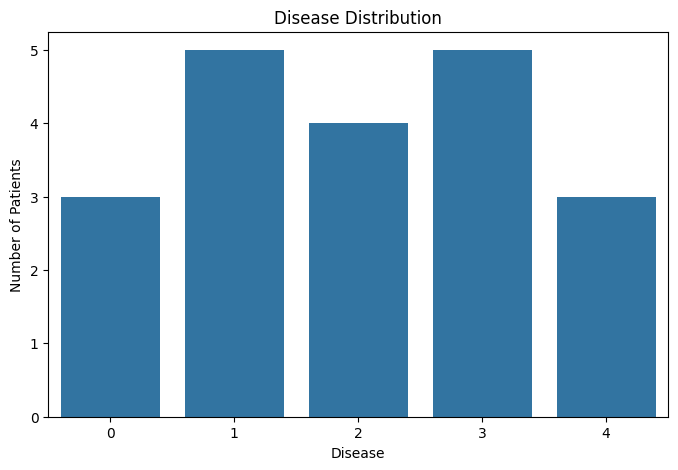

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x="Diagnosis", data=df)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.show()


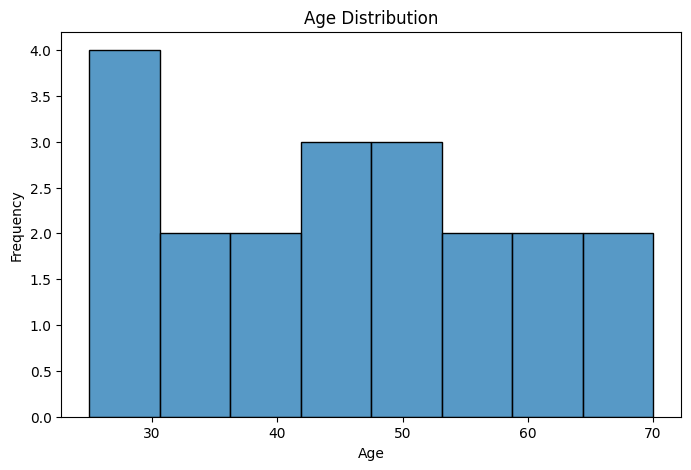

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=8)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

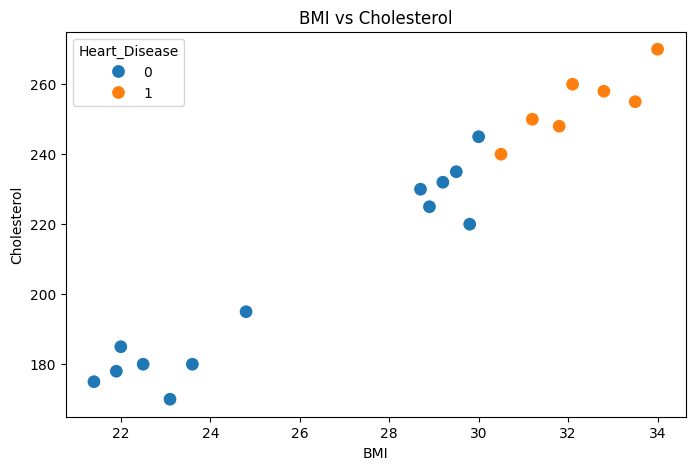

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="BMI",
    y="Cholesterol",
    hue="Heart_Disease",
    data=df,
    s=100
)

plt.title("BMI vs Cholesterol")
plt.show()

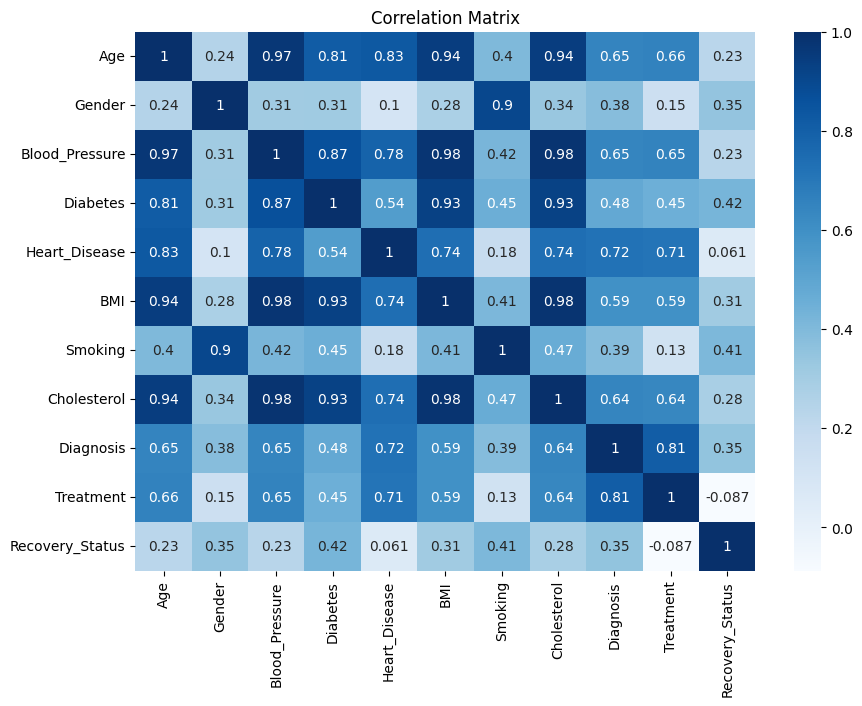

In [13]:
plt.figure(figsize=(10,7))
sns.heatmap(df.drop('Patient_ID', axis=1).corr(), annot=True, cmap="Blues")

plt.title("Correlation Matrix")
plt.show()